In [12]:
import ipympl
ipympl.__version__
%matplotlib widget

In [13]:
import os
print(os.getcwd())
if not os.getcwd().endswith('degradation_simulation'):
    os.chdir('degradation_simulation')
    print(f"Changed working directory to {os.getcwd()}")

/home/duarte/Desktop/PeakStone/Multichemistry/degradation_simulation


In [14]:
import numpy as np
import pandas as pd
from load_data import load_cell_data, load_energy_data_household, load_energy_data_fast_regulation
import matplotlib.pyplot as plt
import pandas as pd
from main_v3 import get_battery_parameters, dispatch_battery, compute_damage_paper


In [15]:
cells_df = load_cell_data("../data/cells.json")

In [16]:
df = load_energy_data_household("../data/household_data_15min_singleindex_filtered.csv")
dt = 1/4  # intervalo de tempo em horas (15 minutos)

print("Dados carregados:")
print("Len df:", len(df))

Dados carregados:
Len df: 56773


Potência máxima da carga: 7.77 kW


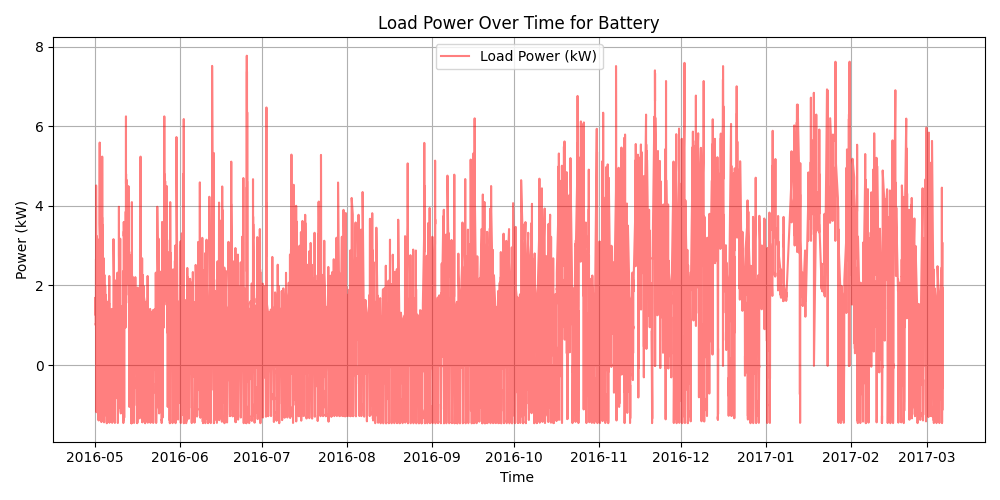

In [17]:
df_cut = df[(df["E_pv_interval_kwh"] > 0) & (df["cet_cest_timestamp"] > "2016-05")].copy()
df_cut["P_pv_inst_kW"] = df_cut["E_pv_interval_kwh"] / dt
df_cut["P_load_inst_kW"] = df_cut["E_load_interval_kwh"] / dt - df_cut["P_pv_inst_kW"]

df_cut["P_pv_inst_kW"] = 0.0  

max_power = max(df_cut["P_load_inst_kW"])
print(f"Potência máxima da carga: {max_power:.2f} kW")

plt.figure(figsize=(10, 5))
plt.plot(df_cut["cet_cest_timestamp"], df_cut["P_load_inst_kW"], label="Load Power (kW)", color='red', alpha=0.5)
plt.xlabel("Time ")
plt.ylabel("Power (kW)")
plt.title("Load Power Over Time for Battery")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

chemistries = ["LFP", "NMC", "LTO", "Sodium"]

In [18]:
# Calcular a potência RMS
power_rms = np.sqrt(np.mean(df_cut["P_load_inst_kW"]**2))

print(f"Potência RMS da carga: {power_rms:.2f} kW")
# Dimensionar a bateria para suportar essa potência ao maximo c_rate contínuo
bat_energy_kWh_cont = {c: 0 for c in chemistries}
n_cells_cont = {c: 0 for c in chemistries}
for chem in chemistries:
    cell_row = cells_df[cells_df["Composition"] == chem].iloc[0]
    bat_energy_kWh_cont[chem] = power_rms/cell_row["MaxContinuousDischargeRate"]
    n_cells_cont[chem] = int((bat_energy_kWh_cont[chem]*1000) / cell_row["E_cell_Wh"])
    print(f"Energia da bateria dimensionada para {cell_row['MaxContinuousDischargeRate']} C continuo para {chem}: {bat_energy_kWh_cont[chem]:.2f} kWh, Número de células: {n_cells_cont[chem]}")

Potência RMS da carga: 1.91 kW
Energia da bateria dimensionada para 0.5 C continuo para LFP: 3.82 kWh, Número de células: 23
Energia da bateria dimensionada para 1.0 C continuo para NMC: 1.91 kWh, Número de células: 4
Energia da bateria dimensionada para 1.0 C continuo para LTO: 1.91 kWh, Número de células: 19
Energia da bateria dimensionada para 0.5 C continuo para Sodium: 3.82 kWh, Número de células: 17


In [19]:
bat_energy_kWh_peak = {c: 0 for c in chemistries}
n_cells_peak = {c: 0 for c in chemistries}
for chem in chemistries:
    cell_row = cells_df[cells_df["Composition"] == chem].iloc[0]
    max_power = max(df_cut["P_load_inst_kW"])
    print(f"Potência máxima da carga: {max_power:.2f} kW")
    bat_energy_kWh_peak[chem] = max_power/cell_row["PeakDischargeRate"]
    n_cells_peak[chem] = int((bat_energy_kWh_peak[chem]*1000) / cell_row["E_cell_Wh"])
    print(f"Energia da bateria dimensionada para {cell_row['PeakDischargeRate']} C pico para {chem}: {bat_energy_kWh_peak[chem]:.2f} kWh, Número de células: {n_cells_peak[chem]}")

Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 5 C pico para LFP: 1.55 kWh, Número de células: 9
Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 3 C pico para NMC: 2.59 kWh, Número de células: 6
Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 12 C pico para LTO: 0.65 kWh, Número de células: 6
Potência máxima da carga: 7.77 kW
Energia da bateria dimensionada para 5 C pico para Sodium: 1.55 kWh, Número de células: 7


In [20]:
bat_energy_kWh = {c: 0 for c in chemistries}
n_cells = {c: 0 for c in chemistries}
for chem in chemistries:
    if n_cells_cont[chem] > n_cells_peak[chem]:
        bat_energy_kWh[chem] = bat_energy_kWh_cont[chem]
        n_cells[chem] = n_cells_cont[chem]
    else:
        bat_energy_kWh[chem] = bat_energy_kWh_peak[chem]
        n_cells[chem] = n_cells_peak[chem]
    print(f"Energia da bateria final para {chem}: {bat_energy_kWh[chem]:.2f} kWh, Número de células: {n_cells[chem]}")

Energia da bateria final para LFP: 3.82 kWh, Número de células: 23
Energia da bateria final para NMC: 2.59 kWh, Número de células: 6
Energia da bateria final para LTO: 1.91 kWh, Número de células: 19
Energia da bateria final para Sodium: 3.82 kWh, Número de células: 17



--- Simulação de lifetime para cada química ---


--- Resultados para química: LFP ---
Energia total da bateria para LFP: 3.68 kWh
LFP: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: divide by zero encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100
/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: invalid value encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100


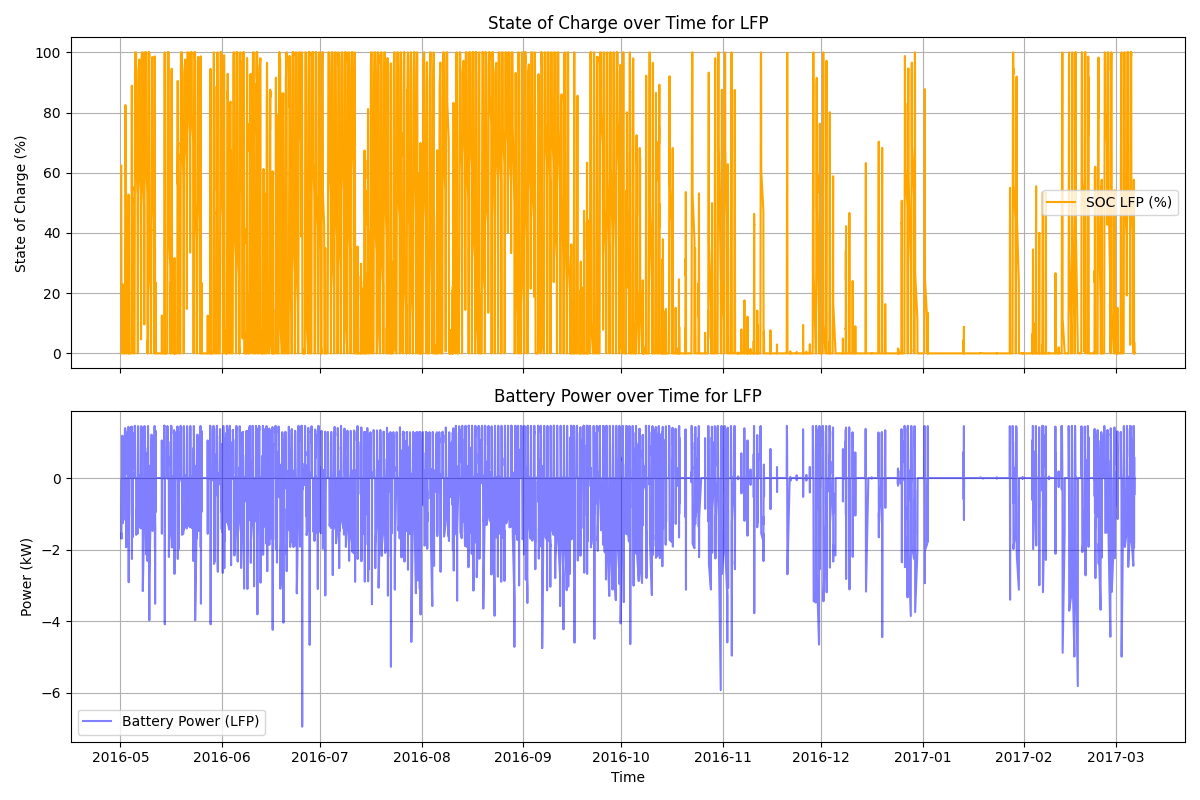

Variação de SOC (%) para NMC: nan%
Calculating damage for chemistry: LFP, len of P_batt: 14029, len of SOC_P_hist: 14029
Debug: Cycle from 3243 to 3269, P_batt: Max: 1.4599609360000159 Min: -6.954833983999833, C_rate_mean_ch: 0.30234552931353476, C_rate_mean_dis: 0.9099845554347905, Cycle: 166
Total cycles identified: 642
DoD samples: Min = 0.0000298529, Max = 1.0000, Mean = 0.4938
DoD=0 indexes: [32, 67, 304, 548, 568]
Init_Cycle: 2386, End_Cycle: 2405
Init_Cycle Date: 2016-06-11 08:15:00+02:00, End_Cycle Date: 2016-06-11 13:00:00+02:00
DoD[120]: 0.8955499397282606, C_rate_dis[120]: 0.3017038538043538, C_rate_ch[120]: 0.23413070319693086
SoC at Init_Cycle[120]: 0.0, SoC at End_Cycle[120]: 72.79366876147307


/home/duarte/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/duarte/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


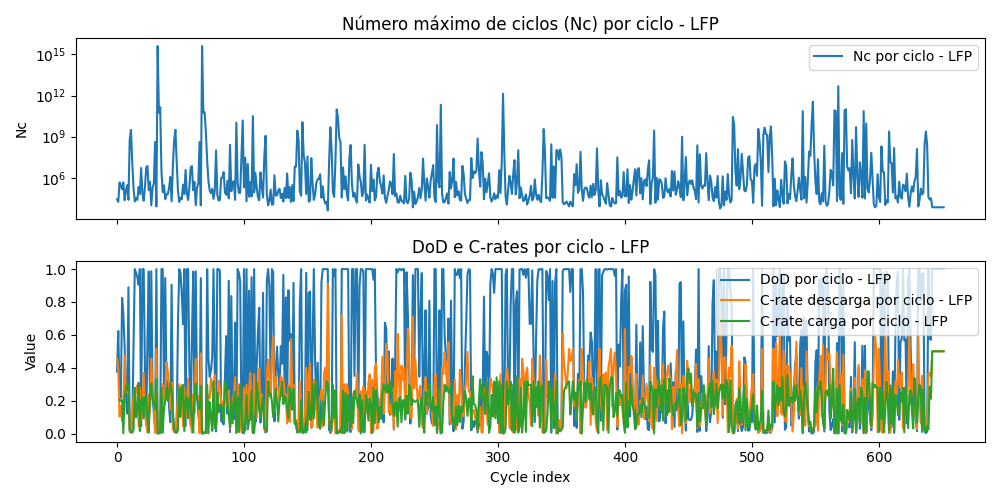

{'LFP': 0.01482135319454844, 'NMC': nan, 'LTO': nan, 'Sodium': nan}
Total de Damage para LFP: 0.0148213532
LFP: Lifetime equivalente: 27.0 anos, Fração de vida consumida: 1.48%


--- Resultados para química: NMC ---
Energia total da bateria para NMC: 2.52 kWh
NMC: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: divide by zero encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100
/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: invalid value encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100
/tmp/ipykernel_165797/3956108079.py:55: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


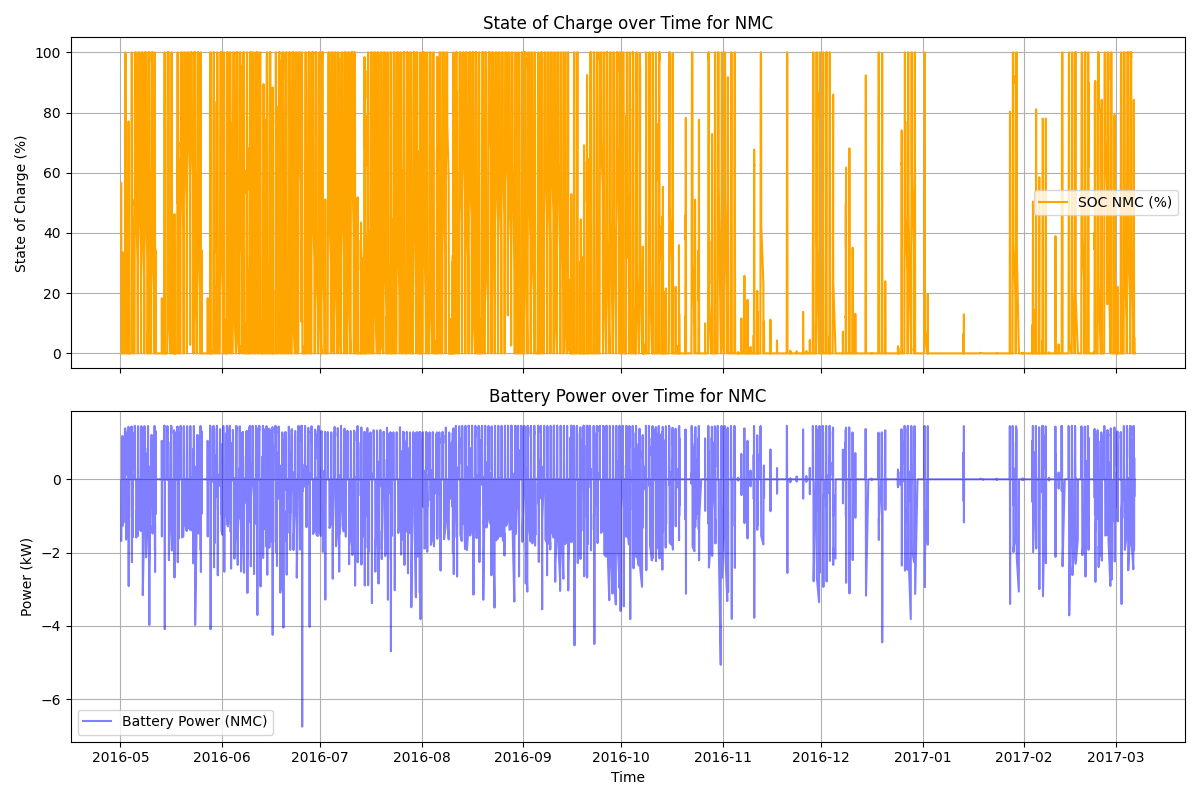

Variação de SOC (%) para NMC: -56.53%
Calculating damage for chemistry: NMC, len of P_batt: 14029, len of SOC_P_hist: 14029
Debug: Cycle from 3243 to 3269, P_batt: Max: 1.4599609360000159 Min: -6.754025467999895, C_rate_mean_ch: 0.44157302372258916, C_rate_mean_dis: 1.2194431421730254, Cycle: 166
Total cycles identified: 642
DoD samples: Min = 0.0000435998, Max = 1.0000, Mean = 0.5472
DoD=0 indexes: [32, 67, 304, 568]
Init_Cycle: 2386, End_Cycle: 2405
Init_Cycle Date: 2016-06-11 08:15:00+02:00, End_Cycle Date: 2016-06-11 13:00:00+02:00
DoD[120]: 1.0, C_rate_dis[120]: 0.44063586220582684, C_rate_ch[120]: 0.3703703703703704
SoC at Init_Cycle[120]: 0.0, SoC at End_Cycle[120]: 75.52022987745407


/home/duarte/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/duarte/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


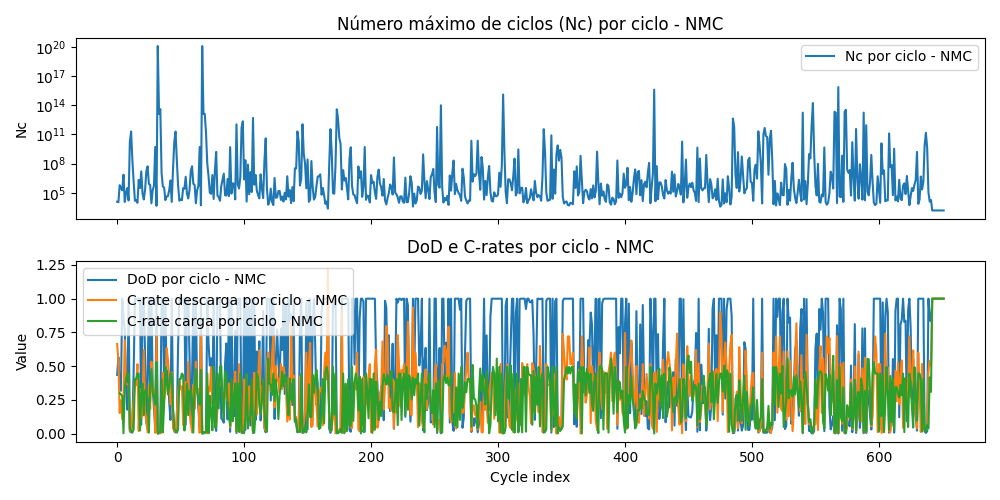

{'LFP': nan, 'NMC': 0.02416018124680011, 'LTO': nan, 'Sodium': nan}
Total de Damage para NMC: 0.0241601812
NMC: Lifetime equivalente: 16.6 anos, Fração de vida consumida: 2.42%


--- Resultados para química: LTO ---
Energia total da bateria para LTO: 1.82 kWh
LTO: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: divide by zero encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100
/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: invalid value encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100


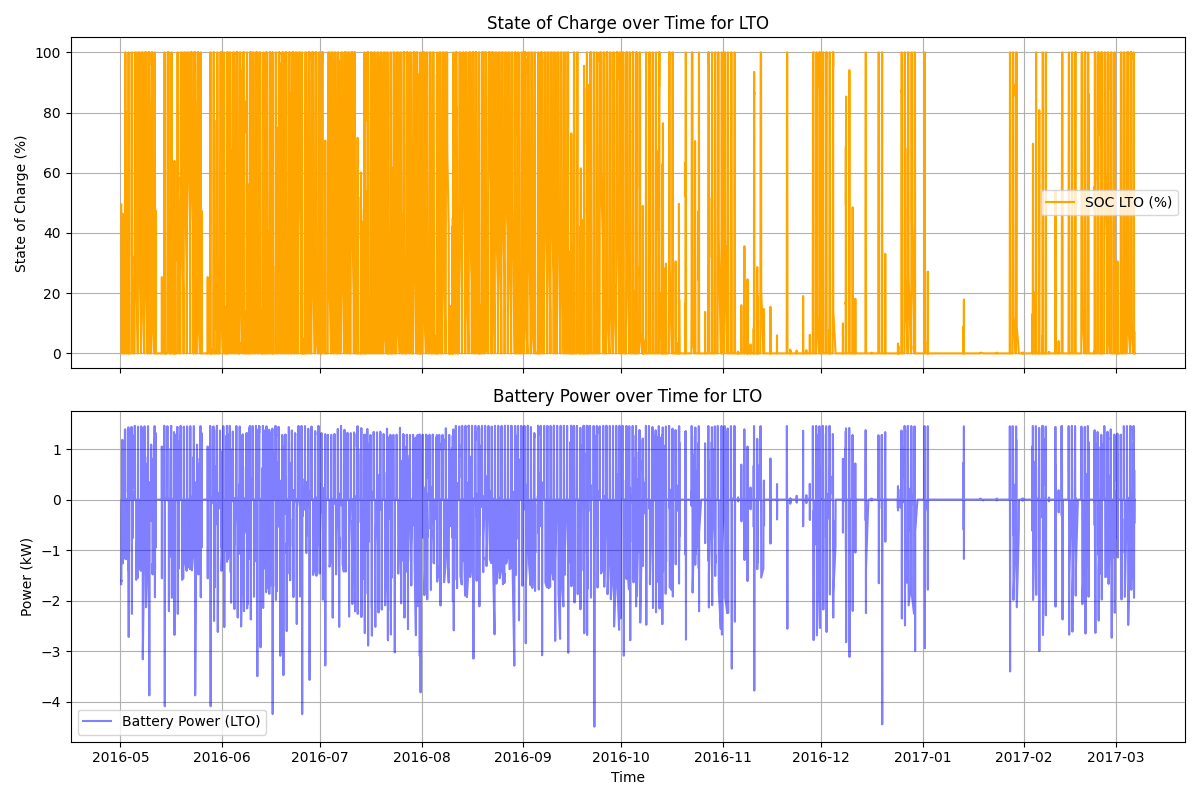

Variação de SOC (%) para NMC: nan%
Calculating damage for chemistry: LTO, len of P_batt: 14029, len of SOC_P_hist: 14029
Total cycles identified: 642
DoD samples: Min = 0.0000602294, Max = 1.0000, Mean = 0.5817
DoD=0 indexes: [32, 67, 568]
Init_Cycle: 2386, End_Cycle: 2405
Init_Cycle Date: 2016-06-11 08:15:00+02:00, End_Cycle Date: 2016-06-11 13:00:00+02:00
DoD[120]: 1.0, C_rate_dis[120]: 0.6087007576754506, C_rate_ch[120]: 0.4938271604938271
SoC at Init_Cycle[120]: 0.0, SoC at End_Cycle[120]: 66.18329124025274


/home/duarte/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/duarte/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


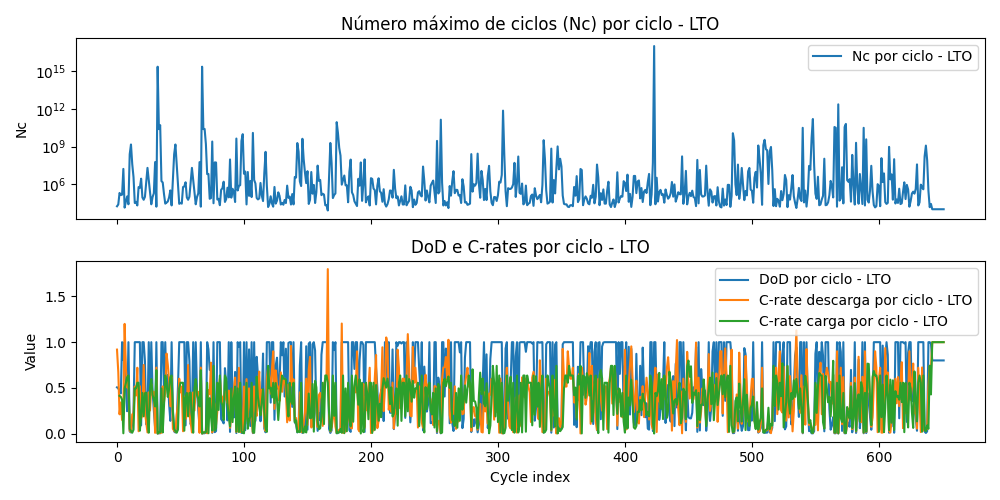

{'LFP': nan, 'NMC': nan, 'LTO': 0.010275248786487487, 'Sodium': nan}
Total de Damage para LTO: 0.0102752488
LTO: Lifetime equivalente: 39.0 anos, Fração de vida consumida: 1.03%


--- Resultados para química: Sodium ---
Energia total da bateria para Sodium: 3.63 kWh
Sodium: MAX SOC(%) = 100.00%, MIN SOC(%) = -0.00%


/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: divide by zero encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100
/tmp/ipykernel_165797/3956108079.py:19: RuntimeWarning: invalid value encountered in divide
  SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100


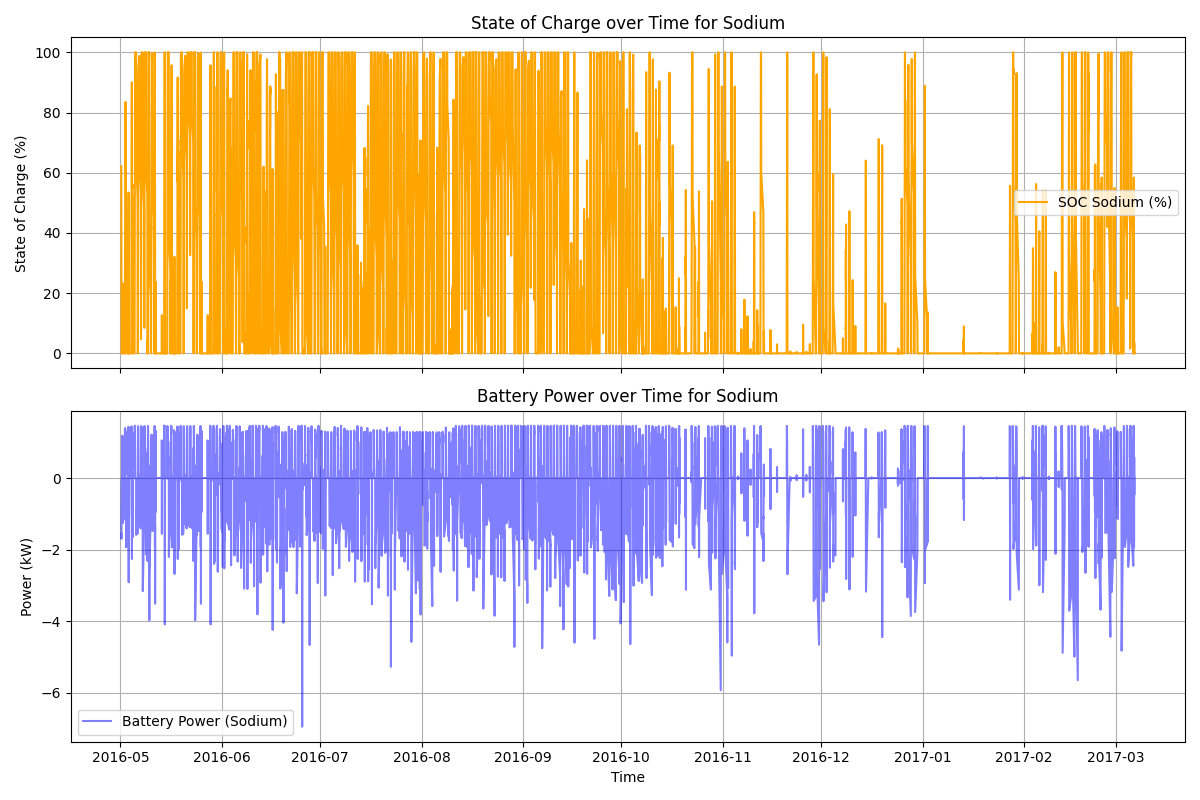

Variação de SOC (%) para NMC: nan%
Calculating damage for chemistry: Sodium, len of P_batt: 14029, len of SOC_P_hist: 14029
Debug: Cycle from 3243 to 3269, P_batt: Max: 1.4599609360000159 Min: -6.954833983999833, C_rate_mean_ch: 0.3061937524248525, C_rate_mean_dis: 0.9101116378397054, Cycle: 166
Total cycles identified: 642
DoD samples: Min = 0.0000302328, Max = 1.0000, Mean = 0.4967
DoD=0 indexes: [32, 67, 304, 548, 568]
Init_Cycle: 2386, End_Cycle: 2405
Init_Cycle Date: 2016-06-11 08:15:00+02:00, End_Cycle Date: 2016-06-11 13:00:00+02:00
DoD[120]: 0.9069484081733744, C_rate_dis[120]: 0.3055439097351282, C_rate_ch[120]: 0.2371106949472874
SoC at Init_Cycle[120]: 0.0, SoC at End_Cycle[120]: 73.72017916538589


/home/duarte/.local/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/duarte/.local/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


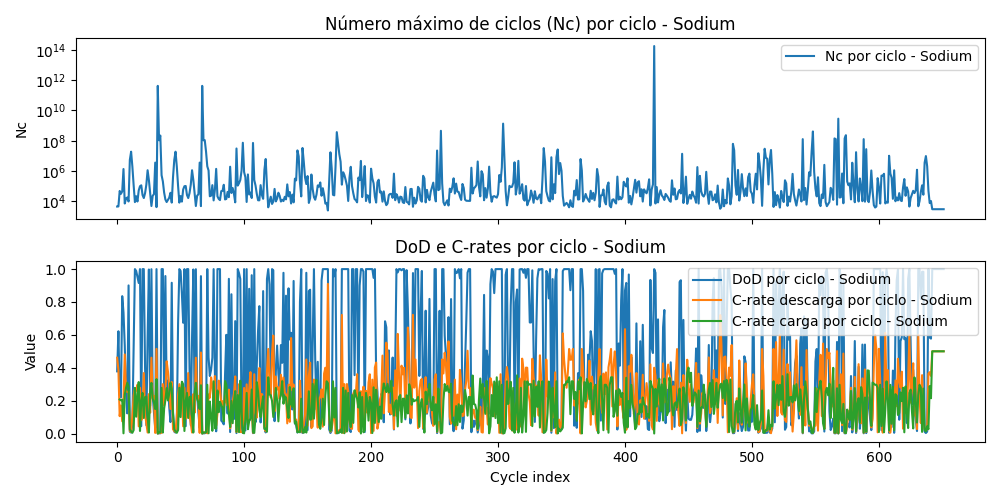

{'LFP': nan, 'NMC': nan, 'LTO': nan, 'Sodium': 0.03640837416102713}
Total de Damage para Sodium: 0.0364083742
Sodium: Lifetime equivalente: 11.0 anos, Fração de vida consumida: 3.64%


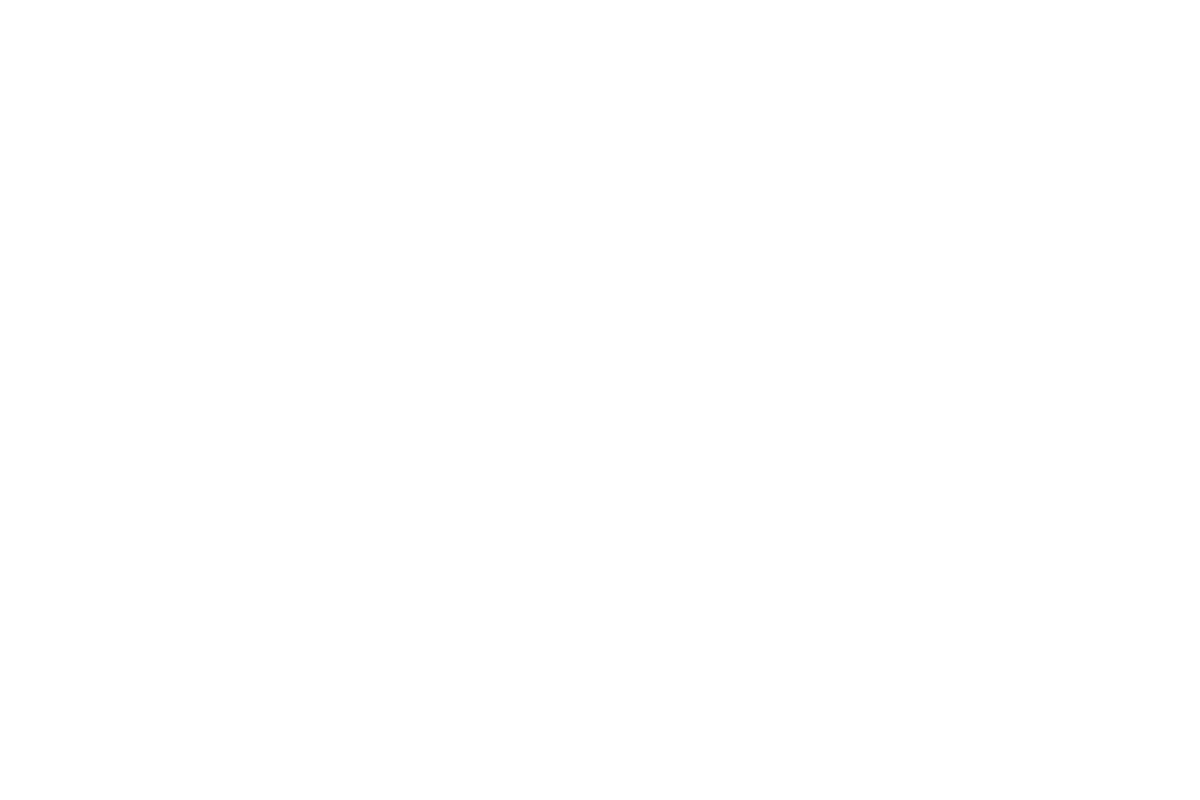

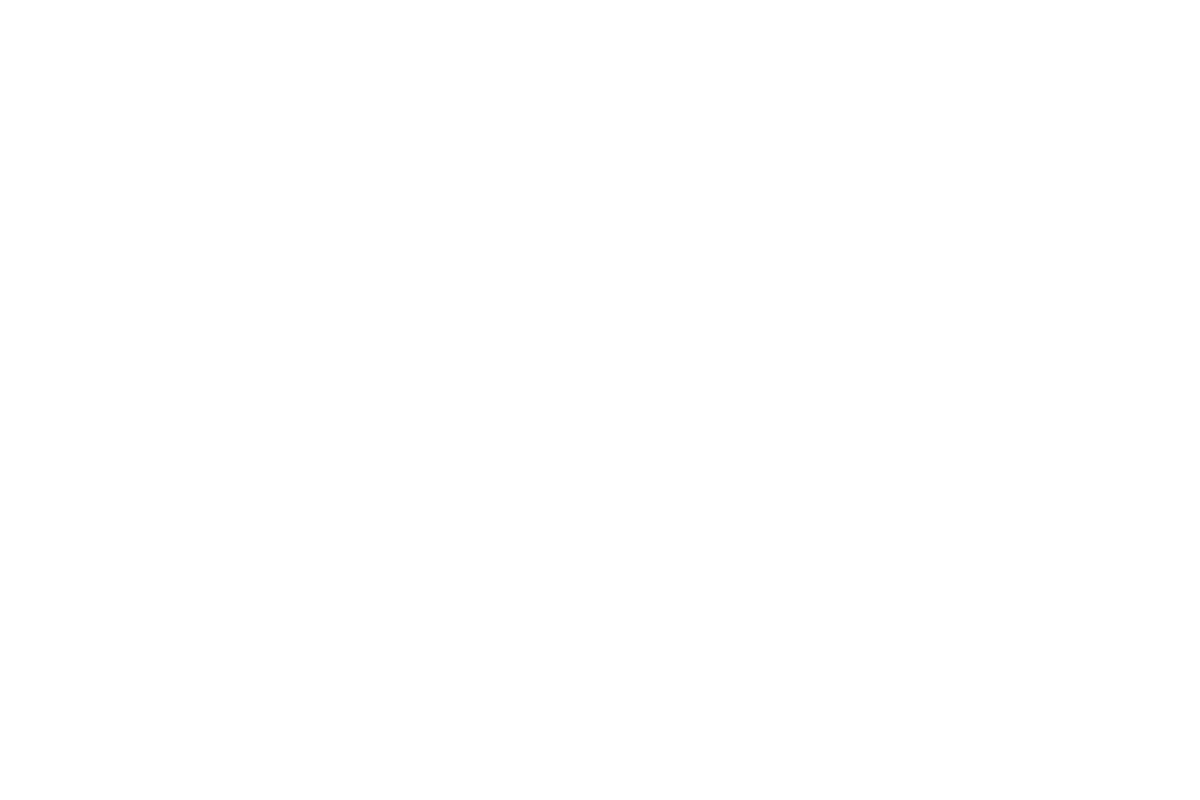

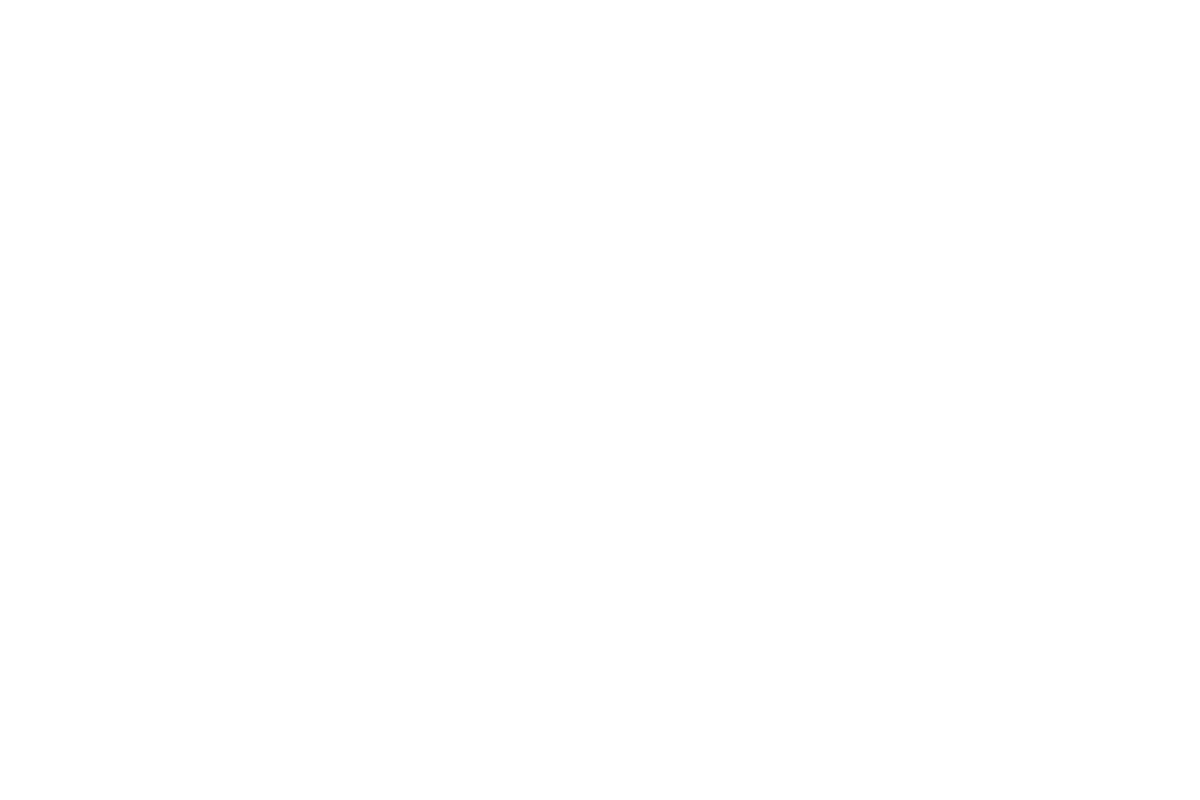

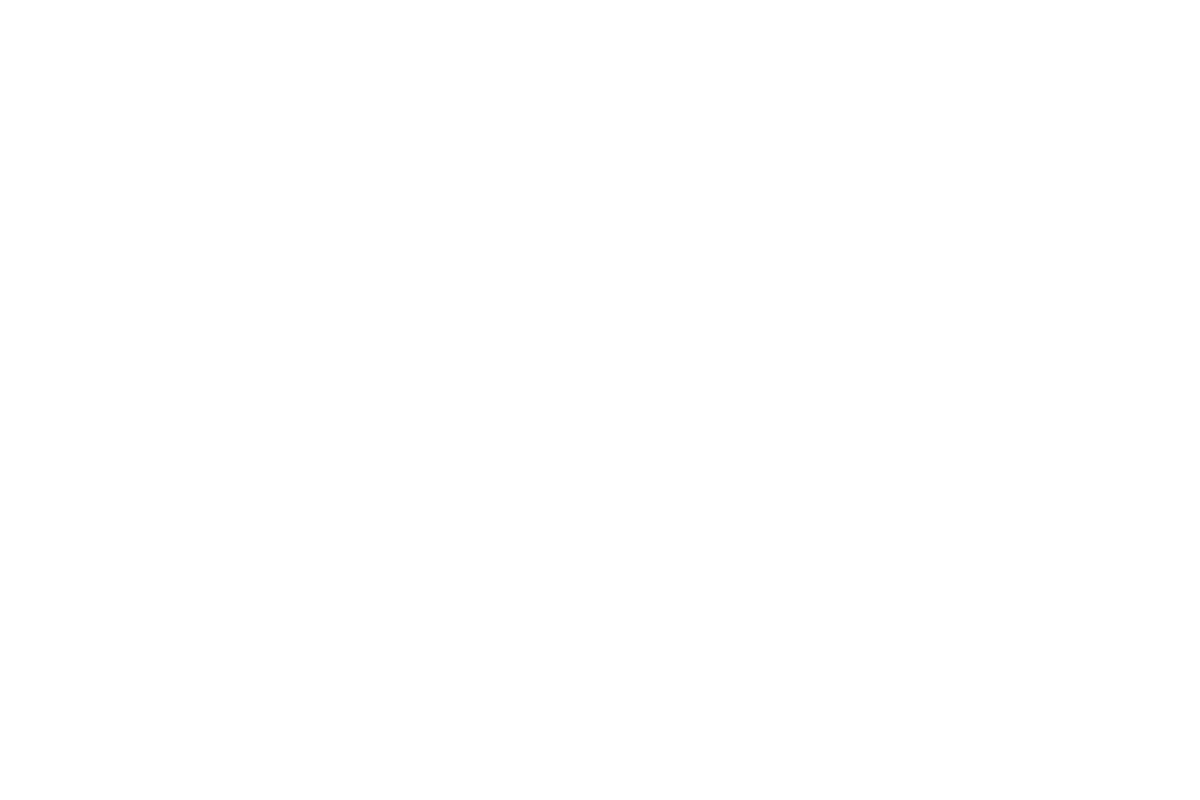

In [ ]:
print("\n--- Simulação de lifetime para cada química ---")
lifetime_years = {}
bat_df = {}
sim_time_hours = len(df_cut) * dt
P_batt = {}
for chem in chemistries:
    print("\n")
    print(f"--- Resultados para química: {chem} ---")
    bat_df[chem] = get_battery_parameters({chem: n_cells[chem]}, cells_df)
    print(f"Energia total da bateria para {chem}: {bat_df[chem].loc[bat_df[chem]['Composition'] == chem, 'E_total_Wh'].values[0]/1000:.2f} kWh")
    P_batt[chem], P_grid, P_batt_all, SOC_hist = dispatch_battery(df_cut, bat_df[chem], dt)
    # Calcular histórico de SOC (%) para a química atual
    # Calcular histórico de SOC (%) para todas as químicas
    SOC_P_hist = {}
    for chem_ in chemistries:
        E_total_kWh = bat_df[chem].loc[bat_df[chem]["Composition"] == chem_, "E_total_Wh"].values[0] / 1000
        SOC_P_hist[chem_] = SOC_hist[chem_]/E_total_kWh * 100
    
    
    P_pv = df_cut["P_pv_inst_kW"].values
    p_batt = P_batt[chem][chem]

    soc = SOC_hist[chem]
    soc_percent = soc / (bat_df[chem].loc[bat_df[chem]["Composition"] == chem, "E_total_Wh"].values[0] / 1000) * 100



    plt.figure(figsize=(12, 8))

    # Plot 1: Battery Power
    """  plt.subplot(2, 1, 1)
    plt.plot(df_cut["cet_cest_timestamp"], P_batt[chem][chem], label=f"Battery Power ({chem})", color='blue')
    plt.plot(df_cut["cet_cest_timestamp"], P_grid, label="Grid Power", color='purple', alpha=0.5)
    plt.plot(df_cut["cet_cest_timestamp"], P_pv, label="PV Power", color='green', alpha=0.5)
    plt.xlabel("Time ")
    plt.ylabel("Power (kW)")
    plt.title(f"Battery Power over Time for {chem}")
    plt.legend()
    plt.grid()

    # Plot 2: SOC (%)
    plt.subplot(2, 1, 2)
    plt.plot(df_cut["cet_cest_timestamp"], soc_percent, label=f"SOC {chem} (%)", color='orange')
    plt.xlabel("Time ")
    plt.ylabel("State of Charge (%)")
    plt.title(f"State of Charge over Time for {chem}")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show() """

    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axs[0].plot(df_cut["cet_cest_timestamp"], soc_percent, label=f"SOC {chem} (%)", color='orange')
    axs[0].set_ylabel("State of Charge (%)")
    axs[0].set_title(f"State of Charge over Time for {chem}")
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(df_cut["cet_cest_timestamp"], p_batt, label=f"Battery Power ({chem})", color='blue', alpha=0.5)
    axs[1].set_xlabel("Time")
    axs[1].set_ylabel("Power (kW)")
    axs[1].set_title(f"Battery Power over Time for {chem}")
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

    # Calcular histórico de SOC (%) gasto em cada química 
    chem_ = "NMC"
    SOC_P_hist_quimica=SOC_P_hist[chem_][-1]-SOC_P_hist[chem_][0]
    print(f"Variação de SOC (%) para {chem_}: {SOC_P_hist_quimica:.2f}%")


    
    NC, Damage = compute_damage_paper(P_batt[chem], bat_df[chem], dt, SOC_P_hist, df_cut)



    print(Damage)
    print(f"Total de Damage para {chem}: {Damage[chem]:.10f}")
    life_fraction =  Damage[chem]  # Fração de vida consumida em anos
    sim_time_years = len(df_cut) * dt / 8760 
    lifetime_years[chem] = sim_time_years / life_fraction
    print(f"{chem}: Lifetime equivalente: {lifetime_years[chem]:.1f} anos, Fração de vida consumida: {life_fraction:.2%}")
    """ life_fraction = damage[chem] 
    sim_time_hours = len(df_cut) * dt
    lifetime_years[chem] = sim_time_hours / life_fraction 
    print(f"{chem}: Lifetime equivalente: {lifetime_years[chem]:.1f} anos, Fração de vida consumida: {life_fraction:.2%}")
    print(f"  C-rate médio: {c_rate_mean[chem][chem]:.2f}, C-rate médio ligado: {c_rate_mean_on[chem]:.2f}, C-rate máximo: {c_rate_max[chem][chem]:.2f}")
    print(f"  Ciclos totais: {cycles[chem]:.1f}, Ciclos por ano (assumindo 1 ano): {cycles[chem]/(len(df_cut)*dt/8760):.1f}") """

In [22]:
price_battery = {}
price_battery_per_year = {}
price_battery_per_year_per_energy = {}
for chem in chemistries:
    cell_row = cells_df[cells_df["Composition"] == chem].iloc[0]
    price_per_kwh = cell_row["Price"]
    price_battery[chem] = price_per_kwh*bat_energy_kWh[chem]
    price_battery_per_year[chem] = price_battery[chem]/lifetime_years[chem]
    # Custo anual por kWh útil fornecido ao longo da vida útil
    # Integração da energia total fornecida pela bateria (em kWh)
    energia_total_kWh = np.sum(np.abs(P_batt[chem][chem])) * dt  # P_batt em kW, dt em horas
    price_battery_per_year_per_energy[chem] = price_battery[chem] / (energia_total_kWh*(lifetime_years[chem]/(sim_time_hours/(24*365))))
    
    print(f" {chem}: Preço da bateria: {price_battery[chem]:.2f} €, Custo anual: {price_battery_per_year[chem]:.2f} €, Custo anual por kWh útil: {price_battery_per_year_per_energy[chem]:.4f} €/kWh")

 LFP: Preço da bateria: 343.47 €, Custo anual: 12.72 €, Custo anual por kWh útil: 0.0031 €/kWh
 NMC: Preço da bateria: 233.14 €, Custo anual: 14.07 €, Custo anual por kWh útil: 0.0045 €/kWh
 LTO: Preço da bateria: 858.68 €, Custo anual: 22.04 €, Custo anual por kWh útil: 0.0091 €/kWh
 Sodium: Preço da bateria: 228.98 €, Custo anual: 20.82 €, Custo anual por kWh útil: 0.0052 €/kWh


In [23]:
from IPython.display import display, Latex
df = pd.DataFrame({
    'Química': chemistries,
    'Custo da Bateria (€)': [price_battery[chem] for chem in chemistries],
    'Custo Anual da Bateria (€)': [price_battery_per_year[chem] for chem in chemistries],
    'Custo Anual por kWh Útil (€ / kWh)': [
        price_battery_per_year_per_energy[chem]
        for chem in chemistries
    ],
})

# Gera LaTeX da tabela sem índice
latex_table = df.to_latex(index=False, escape=False, column_format='lcccccc')

# Envolve em \small para reduzir a fonte
latex_table = r'\begin{small}' + '\n' + latex_table + '\n' + r'\end{small}'

# Display como LaTeX interpretado
display(Latex(latex_table))

<IPython.core.display.Latex object>

In [24]:
print("\n--- Resumo dos resultados de lifetime ---")
print(f"{'Química':<10} {'Lifetime (anos)':<20} {'Bateria Energy (kWh)':<25} {'Número de Células':<20} {'C-rate Máximo':<15} {'C-rate Médio':<15} {'Preço Bateria':<15} {'Preço por Ano':<15}")
for chem in chemistries:
    print(f"{chem:<10} {lifetime_years[chem]:<20.1f} {bat_energy_kWh[chem]:<25.2f} {n_cells[chem]:<20} {price_battery[chem]:<15.2f} {price_battery[chem]/lifetime_years[chem]:<15.2f}")


--- Resumo dos resultados de lifetime ---
Química    Lifetime (anos)      Bateria Energy (kWh)      Número de Células    C-rate Máximo   C-rate Médio    Preço Bateria   Preço por Ano  
LFP        27.0                 3.82                      23                   343.47          12.72          
NMC        16.6                 2.59                      6                    233.14          14.07          
LTO        39.0                 1.91                      19                   858.68          22.04          
Sodium     11.0                 3.82                      17                   228.98          20.82          


In [26]:
from IPython.display import display, Latex

df = pd.DataFrame({
    'Química': chemistries,
    'Lifetime (anos)': [lifetime_years[chem] for chem in chemistries],
    'Bateria Energy (kWh)': [bat_energy_kWh[chem] for chem in chemistries],
    'Número de Células': [n_cells[chem] for chem in chemistries],
})

# Gera LaTeX da tabela sem índice
latex_table = df.to_latex(index=False, escape=False, column_format='lcccccc')

# Envolve em \small para reduzir a fonte
latex_table = r'\begin{small}' + '\n' + latex_table + '\n' + r'\end{small}'

# Display como LaTeX interpretado
display(Latex(latex_table))

<IPython.core.display.Latex object>